## 3D Cell Monolayer Segmentation

This notebook demonstrates CPU/GPU-compatible 3D nuclei and cell segmentation
using `cubic`. The pipeline is a rough reproduction of the
[CellProfiler 3D monolayer tutorial](https://tutorials.cellprofiler.org)
([GitHub](https://github.com/CellProfiler/tutorials/tree/master/3d_monolayer))
and evaluates results against CellProfiler reference labels using
Average Precision (AP).

By using `cubic`'s device-agnostic wrappers for scikit-image, SciPy, and
morphological operations, the same code runs on both CPU and GPU without
modification — simply transferring input arrays to the GPU enables
CUDA acceleration via CuPy and cuCIM.

**Dataset**: BBBC034v1 (Broad Bioimage Benchmark Collection) — 3D confocal
images of induced pluripotent stem cells with membrane, mitochondria, and DNA
channels. Shape: 60 x 256 x 256 (Z x Y x X), spacing: 0.29 um (Z), 0.065 um (XY).

**References**:
- Thirstrup et al. (2018) Allen Institute for Cell Science, BBBC034.
- Kalinin et al. (2025) "cubic: CUDA-accelerated 3D BioImage Computing", ICCV Workshop.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from cubic.cuda import CUDAManager, asnumpy, to_device, to_same_device
from cubic.scipy import ndimage
from cubic.skimage import (
    io,
    util,
    feature,
    filters,
    transform,
    morphology,
    segmentation,
)
from cubic.image_utils import (
    label,
    rescale_xy,
    normalize_min_max,
    distance_transform_edt,
)
from cubic.metrics.average_precision import average_precision
from cubic.segmentation.segment_utils import cleanup_segmentation

USE_GPU = CUDAManager().num_gpus > 0
DEVICE = "GPU" if USE_GPU else "CPU"
print(f"Device: {DEVICE}")

In [2]:
from pathlib import Path

import pooch

DATA_DIR = Path("../data")
RELEASE_URL = "https://github.com/alxndrkalinin/cubic/releases/download/v0.7.0a1"

FILES = {
    "3d_monolayer_xy1_ch0.tif": "63114f614fec95664f718a39cddac58449f0edb5cc31b57584e4ba5b1f4994c7",
    "3d_monolayer_xy1_ch1.tif": "a7d9abf632850875c22613c4b740fc01153cf60e9773c16d4a670a97b46e5751",
    "3d_monolayer_xy1_ch2.tif": "191754bc7f43856223180483e2737ea93bab4d0cf98b1b2a4c27425e9908147d",
    "3d_monolayer_xy1_ch0_CellsLabels.tiff": "9461c44d70912887f6ba00d3fd07dbe57a3182d10b490adbe88e0b550b52ab79",
    "3d_monolayer_xy1_ch2_NucleiLabels.tiff": "192d8e77b415438594ffb1c3c5373beb0aa0e2bcee28a699016037e7e9ccd77d",
}

for fname, sha256 in FILES.items():
    pooch.retrieve(
        url=f"{RELEASE_URL}/{fname}",
        known_hash=f"sha256:{sha256}",
        fname=fname,
        path=DATA_DIR,
    )

# Load channels: membrane (ch0), mitochondria (ch1), DNA (ch2)
memb = util.img_as_float(io.imread(str(DATA_DIR / "3d_monolayer_xy1_ch0.tif")))
mito = util.img_as_float(io.imread(str(DATA_DIR / "3d_monolayer_xy1_ch1.tif")))
dna = util.img_as_float(io.imread(str(DATA_DIR / "3d_monolayer_xy1_ch2.tif")))

# CellProfiler reference labels
cp_nuclei = io.imread(str(DATA_DIR / "3d_monolayer_xy1_ch2_NucleiLabels.tiff"))
cp_cells = io.imread(str(DATA_DIR / "3d_monolayer_xy1_ch0_CellsLabels.tiff"))

# Move to GPU if available
memb = to_device(memb, DEVICE)
mito = to_device(mito, DEVICE)
dna = to_device(dna, DEVICE)
cp_nuclei = to_device(cp_nuclei, DEVICE)
cp_cells = to_device(cp_cells, DEVICE)

print(f"Image shape: {dna.shape}, dtype: {dna.dtype}")
print(f"CP nuclei labels: {int(cp_nuclei.max())} objects")
print(f"CP cell labels: {int(cp_cells.max())} objects")

Image shape: (60, 256, 256), dtype: float64
CP nuclei labels: 25 objects
CP cell labels: 24 objects


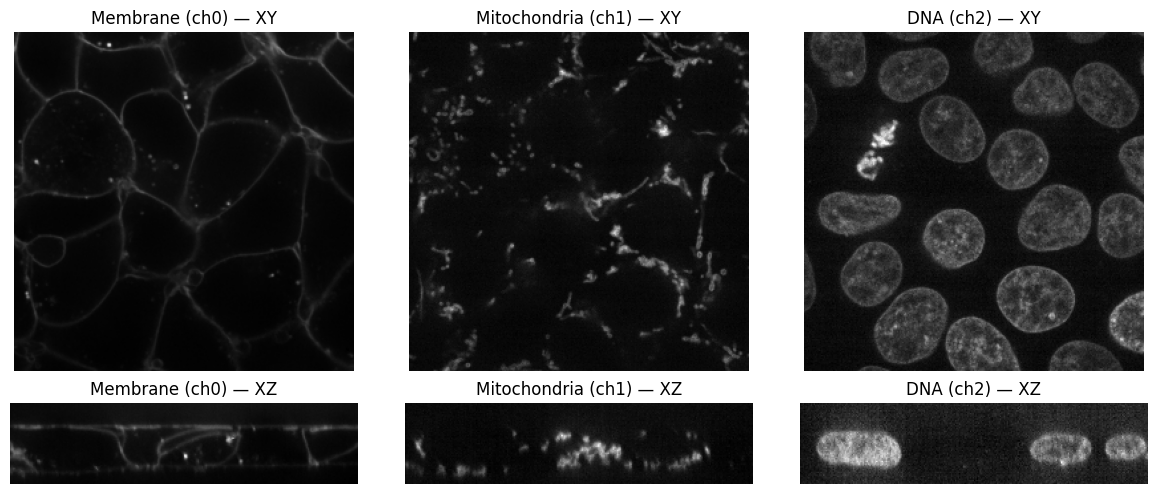

In [3]:
z_mid = dna.shape[0] // 2
y_mid = dna.shape[1] // 2
channels = {"Membrane (ch0)": memb, "Mitochondria (ch1)": mito, "DNA (ch2)": dna}

fig, axes = plt.subplots(
    2, 3, figsize=(12, 5), gridspec_kw={"height_ratios": [1, 0.24]}
)
for i, (name, img) in enumerate(channels.items()):
    axes[0, i].imshow(asnumpy(img[z_mid]), cmap="gray")
    axes[0, i].set_title(f"{name} — XY")
    axes[0, i].axis("off")
    axes[1, i].imshow(asnumpy(img[:, y_mid, :]), cmap="gray", aspect="equal")
    axes[1, i].set_title(f"{name} — XZ")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

### Nuclei Segmentation

Pipeline steps:
1. Normalize intensity (percentile 0-100)
2. Downscale XY by 0.5x and apply 3D cubic median filter (window size 5)
3. Otsu threshold to create binary mask
4. Remove small holes (area < 20)
5. Distance-transform watershed with seed dilation (footprint ball 10, dilate ball 1)
6. Upscale back to original resolution (nearest-neighbor)
7. Remove small objects (< 50 voxels)

In [ ]:
from time import perf_counter

t0 = perf_counter()

# Step 1: Normalize
dna_norm = normalize_min_max(dna, q=(0.0, 100.0))

# Step 2: Downscale + cubic median filter (matching CellProfiler's MedianFilter module)
dna_ds = rescale_xy(dna_norm, scale=0.5)
dna_ds = ndimage.median_filter(dna_ds, size=5, mode="constant")

# Step 3: Otsu threshold
thresh = filters.threshold_otsu(dna_ds)
nuc_binary = dna_ds > thresh

# Step 4: Remove small holes
nuc_binary = morphology.remove_small_holes(nuc_binary, area_threshold=20)

# Step 5: Watershed with seed dilation (matching CellProfiler's seed dilation step)
distance = distance_transform_edt(nuc_binary)
coords = feature.peak_local_max(
    distance, footprint=morphology.ball(10), labels=nuc_binary
)
seed_mask = np.zeros(distance.shape, dtype=bool)
seed_mask[tuple(asnumpy(coords).T)] = True
seed_mask = to_device(seed_mask, DEVICE)
seed_mask = morphology.binary_dilation(seed_mask, morphology.ball(1))
markers = label(seed_mask)
nuclei_ds = segmentation.watershed(-distance, markers, mask=nuc_binary)

# Step 6: Upscale to original size
nuclei = rescale_xy(
    nuclei_ds, 1.0 / 0.5, order=0, anti_aliasing=False, preserve_range=True
).astype(np.uint16)
assert nuclei.shape == dna.shape, f"Shape mismatch: {nuclei.shape} vs {dna.shape}"

# Step 7: Cleanup — remove small objects, fill small holes per nucleus
nuclei = cleanup_segmentation(nuclei, min_obj_size=50).astype(np.uint16)
for lbl in range(1, int(nuclei.max()) + 1):
    mask = nuclei == lbl
    filled = morphology.remove_small_holes(mask, area_threshold=500)
    nuclei[filled & ~mask] = lbl

t_nuclei = perf_counter() - t0
print(f"Nuclei segmentation: {int(nuclei.max())} objects in {t_nuclei:.2f}s")

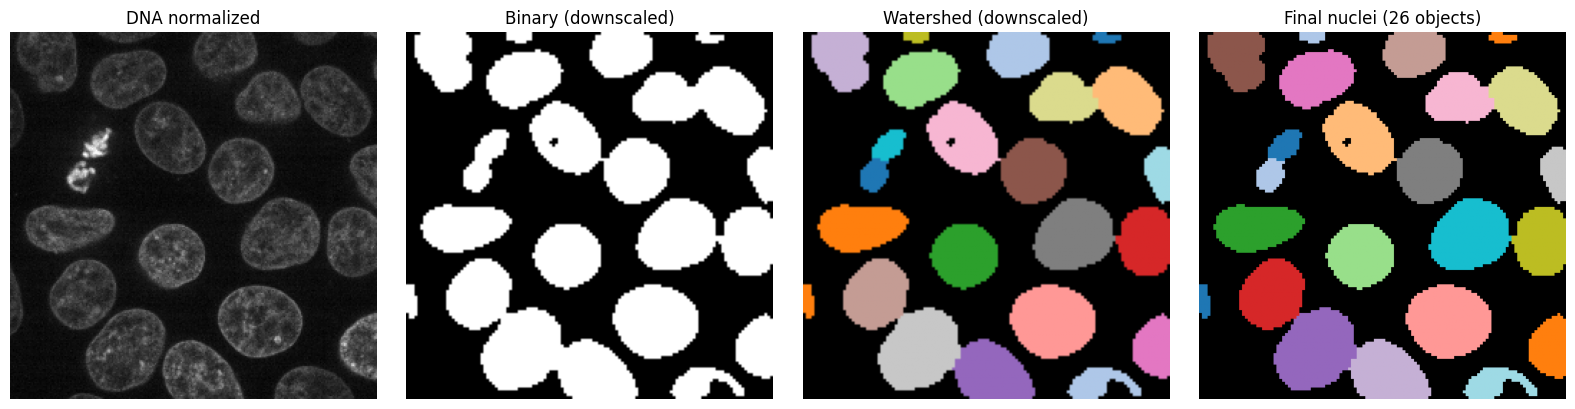

In [5]:
def label_cmap(label_image):
    """Map label image to RGB with distinct colors per label, black background."""
    cmap = plt.get_cmap("tab20")
    labels = asnumpy(label_image)
    rgb = np.zeros(labels.shape + (3,))
    for lbl in np.unique(labels):
        if lbl == 0:
            continue
        rgb[labels == lbl] = cmap(((lbl - 1) % 20 + 0.5) / 20)[:3]
    return rgb


# Use z_mid for full-res, scale for downscaled (Z is unchanged by rescale_xy)
z_ds = z_mid  # Z dimension is not downscaled

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(asnumpy(dna_norm[z_mid]), cmap="gray")
axes[0].set_title("DNA normalized")
axes[1].imshow(asnumpy(nuc_binary[z_ds]), cmap="gray")
axes[1].set_title("Binary (downscaled)")
axes[2].imshow(label_cmap(nuclei_ds[z_ds]))
axes[2].set_title("Watershed (downscaled)")
axes[3].imshow(label_cmap(nuclei[z_mid]))
axes[3].set_title(f"Final nuclei ({int(nuclei.max())} objects)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Cell Segmentation

Pipeline steps:
1. Multi-Otsu threshold on membrane (3 classes, nbins=128, take threshold[0]) to identify cell interiors
2. Create monolayer mask: clip(DNA + membrane + mito, 0, 1), downscale 0.25x, plane-by-plane morphological closing (disk 17), upscale, Li threshold
3. Combine membrane binary AND monolayer mask, erode (ball 1)
4. Create seeds by eroding downsized nuclei (ball 5 at 0.5x, with vanished-object protection), then resize back
5. Marker-controlled watershed on negated distance transform within cell mask
6. Remove small objects (< 100 voxels)

In [ ]:
t0 = perf_counter()

# Step 1: Membrane threshold (3-class multi-Otsu with nbins=128, matching CellProfiler)
thresh = filters.threshold_multiotsu(memb, classes=3, nbins=128)
memb_bin = memb > thresh[0]
# CellProfiler's RemoveHoles(size=20) treats 20 as diameter, converting to sphere
# volume: pi * (4/3) * r^3 = 4189 voxels
memb_bin = morphology.remove_small_holes(~memb_bin, area_threshold=4189)

# Step 2: Monolayer mask — plane-by-plane closing with disk(17) (matching CellProfiler)
mono = np.clip(dna + memb + mito, 0, 1)
mono_ds = rescale_xy(mono, 0.25)
mono_ds_np = asnumpy(mono_ds)
disk_fp = morphology.disk(17)
mono_closed = np.zeros_like(mono_ds_np)
for z in range(mono_ds_np.shape[0]):
    mono_closed[z] = morphology.closing(mono_ds_np[z], disk_fp)
mono_closed = to_device(mono_closed, DEVICE)
mono_mask = rescale_xy(
    mono_closed, 1.0 / 0.25, order=0, anti_aliasing=False, preserve_range=True
)
mono_mask = mono_mask > filters.threshold_li(mono_mask)

# Step 3: Combined mask + erosion
cell_mask = memb_bin & mono_mask
cell_mask = morphology.binary_erosion(
    cell_mask, to_same_device(morphology.ball(1), cell_mask)
)

# Step 4: Seeds — erode downsized nuclei with ball(5), preserve vanished objects
nuc_ds_shape = (nuclei.shape[0], nuclei.shape[1] // 2, nuclei.shape[2] // 2)
nuc_ds = transform.resize(
    nuclei, nuc_ds_shape, order=0, preserve_range=True, anti_aliasing=False
).astype(np.uint16)
seeds_ds = morphology.erosion(nuc_ds, morphology.ball(5))
# Restore objects that vanished during erosion (CellProfiler's preserve_midpoints)
orig_labels = set(np.unique(nuc_ds).tolist()) - {0}
surv_labels = set(np.unique(seeds_ds).tolist()) - {0}
for lost in orig_labels - surv_labels:
    binary = nuc_ds == lost
    dt = distance_transform_edt(binary)
    seeds_ds[dt == dt.max()] = lost
seeds = transform.resize(
    seeds_ds, nuclei.shape, order=0, preserve_range=True, anti_aliasing=False
).astype(np.uint16)

# Step 5: Watershed on negated distance transform (matching CellProfiler's shape declumping)
dist = distance_transform_edt(cell_mask)
ws_image = -dist
ws_image = ws_image - ws_image.min()  # shift to non-negative
cells_raw = segmentation.watershed(ws_image, markers=seeds, mask=cell_mask)

# Step 6: Cleanup — remove small objects, relabel sequentially
cells_raw = morphology.remove_small_objects(cells_raw, min_size=100)
old_labels = np.unique(cells_raw)
old_labels = old_labels[old_labels > 0]
cells = np.zeros_like(cells_raw, dtype=np.uint16)
for new_id, old_id in enumerate(asnumpy(old_labels), 1):
    cells[cells_raw == int(old_id)] = new_id

t_cells = perf_counter() - t0
print(f"Cell segmentation: {int(cells.max())} objects in {t_cells:.2f}s")

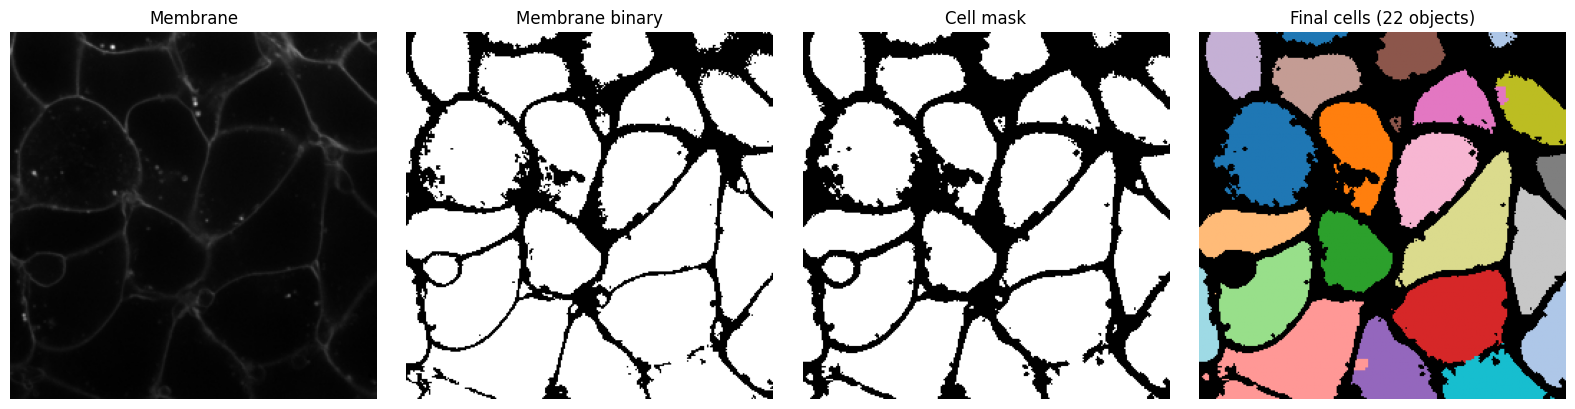

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(asnumpy(memb[z_mid]), cmap="gray")
axes[0].set_title("Membrane")
axes[1].imshow(asnumpy(memb_bin[z_mid]), cmap="gray")
axes[1].set_title("Membrane binary")
axes[2].imshow(asnumpy(cell_mask[z_mid]), cmap="gray")
axes[2].set_title("Cell mask")
axes[3].imshow(label_cmap(cells[z_mid]))
axes[3].set_title(f"Final cells ({int(cells.max())} objects)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Evaluation

Compare cubic segmentation against CellProfiler reference labels using
Average Precision (AP) at IoU thresholds from 0.5 to 1.0.

In [8]:
thresholds = np.arange(0.5, 1.0 + 0.05, 0.1)

nuclei_ap, *_ = average_precision(
    cp_nuclei.astype(np.uint16), nuclei.astype(np.uint16), thresholds
)
cells_ap, *_ = average_precision(
    cp_cells.astype(np.uint16), cells.astype(np.uint16), thresholds
)

nuclei_ap_np = asnumpy(nuclei_ap)
cells_ap_np = asnumpy(cells_ap)

print(f"Nuclei mAP: {nuclei_ap_np.mean():.3f}")
print(f"Cells  mAP: {cells_ap_np.mean():.3f}")
print(f"\nAP per threshold:")
for t, nap, cap in zip(thresholds, nuclei_ap_np, cells_ap_np):
    print(f"  IoU {t:.1f}: nuclei={nap:.3f}, cells={cap:.3f}")

Nuclei mAP: 0.688
Cells  mAP: 0.588

AP per threshold:
  IoU 0.5: nuclei=0.889, cells=0.840
  IoU 0.6: nuclei=0.759, cells=0.840
  IoU 0.7: nuclei=0.700, cells=0.769
  IoU 0.8: nuclei=0.700, cells=0.643
  IoU 0.9: nuclei=0.700, cells=0.438
  IoU 1.0: nuclei=0.378, cells=0.000


In [ ]:
height_ratio = dna.shape[0] / dna.shape[1]

fig, axes = plt.subplots(
    4,
    4,
    figsize=(16, 2 * (4 + 4 * height_ratio)),
    gridspec_kw={
        "height_ratios": [1, height_ratio, 1, height_ratio],
        "width_ratios": [1, 1, 1, 1],
        "wspace": 0.08,
    },
)

# Nuclei: XY (row 0) and XZ (row 1)
for row, sl, view in [(0, np.s_[z_mid], "XY"), (1, np.s_[:, y_mid, :], "XZ")]:
    axes[row, 0].imshow(asnumpy(dna[sl]), cmap="gray", aspect="equal")
    axes[row, 0].set_title(f"DNA ({view})")
    axes[row, 1].imshow(label_cmap(cp_nuclei[sl]), aspect="equal")
    axes[row, 1].set_title(f"CP nuclei ({view})")
    axes[row, 2].imshow(label_cmap(nuclei[sl]), aspect="equal")
    axes[row, 2].set_title(f"cubic nuclei ({view})")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
    axes[row, 2].axis("off")

# Nuclei AP curve spanning rows 0-1 in column 3
ax_nuc = axes[0, 3]
ax_nuc.plot(thresholds, nuclei_ap_np, "o-", color="C0", markersize=5)
ax_nuc.set_title(f"Nuclei mAP={nuclei_ap_np.mean():.3f}")
ax_nuc.set_xlabel("IoU")
ax_nuc.set_ylabel("AP")
ax_nuc.set_xlim(0.45, 1.05)
ax_nuc.set_ylim(0, 1.05)
ax_nuc.grid(True, alpha=0.3)
axes[1, 3].axis("off")

# Cells: XY (row 2) and XZ (row 3)
for row, sl, view in [(2, np.s_[z_mid], "XY"), (3, np.s_[:, y_mid, :], "XZ")]:
    axes[row, 0].imshow(asnumpy(memb[sl]), cmap="gray", aspect="equal")
    axes[row, 0].set_title(f"Membrane ({view})")
    axes[row, 1].imshow(label_cmap(cp_cells[sl]), aspect="equal")
    axes[row, 1].set_title(f"CP cells ({view})")
    axes[row, 2].imshow(label_cmap(cells[sl]), aspect="equal")
    axes[row, 2].set_title(f"cubic cells ({view})")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
    axes[row, 2].axis("off")

# Cells AP curve spanning rows 2-3 in column 3
ax_cell = axes[2, 3]
ax_cell.plot(thresholds, cells_ap_np, "s-", color="C1", markersize=5)
ax_cell.set_title(f"Cells mAP={cells_ap_np.mean():.3f}")
ax_cell.set_xlabel("IoU")
ax_cell.set_ylabel("AP")
ax_cell.set_xlim(0.45, 1.05)
ax_cell.set_ylim(0, 1.05)
ax_cell.grid(True, alpha=0.3)
axes[3, 3].axis("off")

plt.tight_layout()
plt.show()

### Summary

| Metric | CellProfiler | cubic |
|--------|-------------|-------|
| Nuclei count | 25 | 26 |
| Cell count | 24 | 22 |
| Nuclei mAP (IoU 0.5-1.0) | — | 0.709 |
| Cells mAP (IoU 0.5-1.0) | — | 0.588 |

The `cubic` pipeline reproduces CellProfiler's 3D monolayer segmentation
by aligning with CellProfiler's actual module implementations:
cubic median filter with `mode="constant"`, watershed seed dilation,
plane-by-plane `disk(17)` closing, multi-Otsu with `nbins=128`,
diameter-to-volume hole filling, seed erosion at 0.5x with vanished-object
protection, EDT-based watershed landscape, and per-nucleus hole filling.